In [2]:
# import nbformat
# from google.colab import files

# nb_path = "/content/drive/MyDrive/Colab Notebooks/MS4_DETR.ipynb"   # change to your notebook name

# nb = nbformat.read(nb_path, as_version=4)

# # 🔥 Remove widget metadata ONLY
# if "widgets" in nb["metadata"]:
#     del nb["metadata"]["widgets"]

# nbformat.write(nb, nb_path)

# print("✅ Cleaned notebook (outputs preserved)")

# files.download(nb_path)

# DEtection TRansformer (DETR)

Pros:

1. No region proposal tuning
2. Sigle stage pipeline
3. Single loss function

Cons:

1.   Data hungry
2.   Strugles with small objects
3.   Too big to fit in mobile


Requires:

> The follicle data be loaded into drive or directly into colab runtime environment.
> The fine-tuned model is in my drive. I can share if needed (to avoid re-trianing).

Key Param:

The number of decoder queries is set to 100. Given that the median number of objects per image is 12, this value can be reduced to help minimize overlapping predictions.



In [3]:
import os
import xml.etree.ElementTree as ET
from dataclasses import dataclass
from typing import List, Dict, Any

import torch
from torch.utils.data import Dataset
from PIL import Image, ImageDraw, ImageFont

from transformers import (
    DetrImageProcessor,
    DetrForObjectDetection,
    TrainingArguments,
    Trainer
)

import pandas as pd
import matplotlib.pyplot as plt
import json
from transformers import DetrConfig

import cv2
import numpy as np
from torch.utils.data import Dataset
import albumentations as A
from typing import List, Optional


import torch.nn.functional as F

from scipy.optimize import linear_sum_assignment

from torchvision.ops import (
    box_convert,
    generalized_box_iou
)

import torch
from torch.utils.data import DataLoader
from transformers import Trainer
from collections import Counter
from torchvision.ops import box_convert

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!cp -r /content/drive/MyDrive/data /content/


# CONFIG

In [6]:
# ============================================================
# CONFIG: setting params
# ============================================================

@dataclass
class Config:
    # paths
    image_dir: str = "/content/data/Images"
    annot_dir: str = "/content/data/Annotations"
    output_dir: str = "./detr_voc_finetuned"

    # model
    pretrained_model_name: str = "facebook/detr-resnet-50"
    image_size: int = 800
    num_queries: int = 100

    # classes
    class_names: Optional[List[str]] = None

    # training
    per_device_train_batch_size: int = 2
    per_device_eval_batch_size: int = 2
    gradient_accumulation_steps: int = 4 #effective batch size=8
    num_train_epochs: int = 30

    # optimizer
    learning_rate: float = 1e-4
    lr_backbone: float = 1e-5 # we don't want Resnet change too much
    weight_decay: float = 1e-4
    warmup_steps: int = 500
    lr_scheduler_type: str = "cosine"

    # dataloader/checkpoint
    num_workers: int = 2 # dataloader cpu
    save_total_limit: int = 2 # keep only 2

    # imbalance handling: custom flags, not built into DETR
    use_weighted_sampler: bool = True
    use_class_weighted_loss: bool = True
    class_weight_alpha: float = 1.0

    # augmentation
    use_augmentation: bool = True

    # evaluation
    iou_threshold: float = 0.5
    score_threshold: float = 0.05

    def __post_init__(self):
        if self.class_names is None:
            self.class_names = [
                "premium",
                "single",
                "undersize",
                "abnormal",
            ]

        self.label2id = {
            name: i for i, name in enumerate(self.class_names)
        }

        self.id2label = {
            i: name for i, name in enumerate(self.class_names)
        }

        self.num_labels = len(self.class_names)


cfg = Config()

# Pascal VOC class ids must start from 0
id2label = {i: name for i, name in enumerate(cfg.class_names)}
label2id = {name: i for i, name in id2label.items()}


# training and validation split

In [7]:
# load training and validation file names
train_files =[]
val_files = []
with open('/content/data/ImageSets/Main/train.txt') as f:
    lines = f.readlines()
    train_files =[fnm[:-1] for fnm in lines]

with open('/content/data/ImageSets/Main/val.txt') as f:
    lines = f.readlines()
    val_files =[fnm[:-1] for fnm in lines]

# XML Parser

In [28]:
def scale_box_xyxy(box, scale, img_w, img_h):
    x1, y1, x2, y2 = box

    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    bw = (x2 - x1) * scale
    bh = (y2 - y1) * scale

    new_box = [
        cx - bw / 2,
        cy - bh / 2,
        cx + bw / 2,
        cy + bh / 2,
    ]

    return clip_box_xyxy(new_box, img_w, img_h)


def downscale_box_xyxy(box, scale):
    x1, y1, x2, y2 = box

    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    bw = (x2 - x1) / scale
    bh = (y2 - y1) / scale

    return [
        cx - bw / 2,
        cy - bh / 2,
        cx + bw / 2,
        cy + bh / 2,
    ]


def downscale_boxes_xyxy(boxes, scale):
    boxes = boxes.clone()

    cx = (boxes[:, 0] + boxes[:, 2]) / 2
    cy = (boxes[:, 1] + boxes[:, 3]) / 2
    bw = (boxes[:, 2] - boxes[:, 0]) / scale
    bh = (boxes[:, 3] - boxes[:, 1]) / scale

    boxes[:, 0] = cx - bw / 2
    boxes[:, 1] = cy - bh / 2
    boxes[:, 2] = cx + bw / 2
    boxes[:, 3] = cy + bh / 2

    return boxes

In [9]:

# ============================================================
# XML Parser and bbox fixer
# ============================================================

def clip_box_xyxy(box, width, height):
    x1, y1, x2, y2 = box
    x1 = max(0.0, min(float(x1), width - 1))
    y1 = max(0.0, min(float(y1), height - 1))
    x2 = max(0.0, min(float(x2), width - 1))
    y2 = max(0.0, min(float(y2), height - 1))
    return [x1, y1, x2, y2]

def is_valid_xyxy(box):
    x1, y1, x2, y2 = box
    return (x2 > x1) and (y2 > y1)
#coco style bounding box
def xyxy_to_xywh(box):
    x1, y1, x2, y2 = box
    return [x1, y1, x2 - x1, y2 - y1]

def parse_voc_xml(xml_path: str, label2id: Dict[str, int]) -> Dict[str, Any]:
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.findtext("filename")
    size = root.find("size")
    width = int(size.findtext("width"))
    height = int(size.findtext("height"))

    objects = []
    for obj in root.findall("object"):
        name = obj.findtext("name")
        if name is None:
            name = obj.findtext("class")
        if name is None:
            continue

        name = name.strip().lower()
        if name not in label2id:
            continue

        bndbox = obj.find("bndbox")
        if bndbox is None:
            continue

        xmin = float(bndbox.findtext("xmin"))
        ymin = float(bndbox.findtext("ymin"))
        xmax = float(bndbox.findtext("xmax"))
        ymax = float(bndbox.findtext("ymax"))

        # Repair reversed coordinates
        x1, x2 = sorted([xmin, xmax])
        y1, y2 = sorted([ymin, ymax])

        # Clip to XML-declared image size
        x1 = max(0.0, min(x1, width - 1))
        y1 = max(0.0, min(y1, height - 1))
        x2 = max(0.0, min(x2, width - 1))
        y2 = max(0.0, min(y2, height - 1))

        if x2 <= x1 or y2 <= y1:
            continue

        difficult = obj.findtext("difficult")
        difficult = int(difficult) if difficult is not None else 0

        objects.append({
            "name": name,
            "class_id": label2id[name],
            "bbox_xyxy": [x1, y1, x2, y2],
            "difficult": difficult,#how difficult is the object to detect
        })

    return {
        "filename": filename,
        "width": width,
        "height": height,
        "objects": objects,
    }



# Data Augmentation

In [10]:
#Augmentation
train_transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.2),

        A.Rotate(
            limit=5,
            border_mode=cv2.BORDER_CONSTANT,
            p=0.4
        ),

        A.RandomBrightnessContrast(
            brightness_limit=0.15,
            contrast_limit=0.15,
            p=0.4
        ),

        A.CLAHE(
            clip_limit=2.0,
            tile_grid_size=(8, 8),
            p=0.3
        ),

        A.Sharpen(
            alpha=(0.1, 0.25),
            lightness=(0.8, 1.2),
            p=0.25
        ),

        A.GaussNoise(p=0.15),
    ],
    bbox_params=A.BboxParams(
        format="pascal_voc",          # [xmin, ymin, xmax, ymax]
        label_fields=["class_labels"],
        min_visibility=0.3
    )
)
val_transform = None


# Dataset Class

In [11]:
class PascalVOCDataset(Dataset):
    def __init__(
        self,
        image_dir,
        annot_dir,
        processor,
        label2id,
        split,
        transform=None,
        box_scale=1.0,
    ):
        self.image_dir = image_dir
        self.annot_dir = annot_dir
        self.processor = processor
        self.label2id = label2id
        self.split = set(split)
        self.transform = transform
        self.box_scale = box_scale

        self.xml_files = sorted([
            f for f in os.listdir(annot_dir)
            if f.endswith(".xml") and os.path.splitext(f)[0] in self.split
        ])

    def __len__(self):
        return len(self.xml_files)

    def __getitem__(self, idx):
        xml_file = self.xml_files[idx]
        xml_path = os.path.join(self.annot_dir, xml_file)

        parsed = parse_voc_xml(xml_path, self.label2id)

        image_filename = parsed["filename"]
        image_path = os.path.join(self.image_dir, image_filename)

        if not os.path.exists(image_path):
            stem = os.path.splitext(xml_file)[0]
            found = False
            for ext in [".jpg", ".jpeg", ".png", ".bmp"]:
                alt_path = os.path.join(self.image_dir, stem + ext)
                if os.path.exists(alt_path):
                    image_path = alt_path
                    found = True
                    break
            if not found:
                raise FileNotFoundError(f"Image not found for XML: {xml_path}")

        image = Image.open(image_path).convert("RGB")
        width, height = image.size

        boxes_xyxy = []
        class_labels = []

        for obj in parsed["objects"]:
            box_xyxy = clip_box_xyxy(obj["bbox_xyxy"], width, height)

            if not is_valid_xyxy(box_xyxy):
                continue

            # scale GT box BEFORE augmentation and processor
            if self.box_scale != 1.0:
                box_xyxy = scale_box_xyxy(
                    box_xyxy,
                    scale=self.box_scale,
                    img_w=width,
                    img_h=height
                )

            if not is_valid_xyxy(box_xyxy):
                continue

            x_min, y_min, x_max, y_max = box_xyxy

            if x_max <= x_min or y_max <= y_min:
                continue

            boxes_xyxy.append([
                float(x_min),
                float(y_min),
                float(x_max),
                float(y_max)
            ])

            class_labels.append(int(obj["class_id"]))

        image_np = np.array(image)

        if self.transform is not None and len(boxes_xyxy) > 0:
            transformed = self.transform(
                image=image_np,
                bboxes=boxes_xyxy,
                class_labels=class_labels
            )

            image_np = transformed["image"]
            boxes_xyxy = list(transformed["bboxes"])
            class_labels = list(transformed["class_labels"])

        height, width = image_np.shape[:2]

        annotations = []
        ann_id = 0

        for box_xyxy, class_id in zip(boxes_xyxy, class_labels):
            box_xyxy = clip_box_xyxy(box_xyxy, width, height)

            if not is_valid_xyxy(box_xyxy):
                continue

            x, y, w, h = xyxy_to_xywh(box_xyxy)

            if w <= 1 or h <= 1:
                continue

            annotations.append({
                "id": ann_id,
                "image_id": idx,
                "category_id": int(class_id),
                "bbox": [float(x), float(y), float(w), float(h)],
                "area": float(w * h),
                "iscrowd": 0,
            })

            ann_id += 1

        target = {
            "image_id": idx,
            "annotations": annotations,
        }

        encoding = self.processor(
            images=image_np,
            annotations=target,
            return_tensors="pt",
        )

        return {
            "pixel_values": encoding["pixel_values"].squeeze(0),
            "labels": encoding["labels"][0],
        }

In [12]:

processor = DetrImageProcessor.from_pretrained(
    cfg.pretrained_model_name,
    size={"shortest_edge": cfg.image_size, "longest_edge": 1333},
)

# Make data ready to be consumed by loader
def collate_fn(batch):
    pixel_values = [item["pixel_values"] for item in batch]
    labels = [item["labels"] for item in batch]

    #Same shape images with in a batch
    padded = processor.pad(pixel_values, return_tensors="pt")

    return {
        "pixel_values": padded["pixel_values"],
        "pixel_mask": padded["pixel_mask"],
        "labels": labels,
    }

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

# Create Dataset

In [13]:
# ============================================================
# Create Dataset
# ============================================================

train_dataset = PascalVOCDataset(
    image_dir=cfg.image_dir,
    annot_dir=cfg.annot_dir,
    processor=processor,
    label2id=label2id,
    split=train_files,
    transform=train_transform,
    box_scale=1.2
)

val_dataset = PascalVOCDataset(
    image_dir=cfg.image_dir,
    annot_dir=cfg.annot_dir,
    processor=processor,
    label2id=label2id,
    split=val_files,
    transform=None,
    box_scale=1.2
)

# balancing classes

In [14]:
import torch
import torch.nn.functional as F
from collections import Counter
from scipy.optimize import linear_sum_assignment
from torchvision.ops import box_convert, generalized_box_iou

# class counts
class_counts = Counter({
    0: 8063,  # premium
    1: 2815,  # single
    2: 917,   # undersize
    3: 422    # abnormal
})

# FIX: torch.tensor needs a list, not a dict
class_weights = torch.tensor(
    [1.0 / class_counts[i] for i in sorted(class_counts.keys())],
    dtype=torch.float
)

# normalize for stable loss scale
class_weights = class_weights / class_weights.mean()

print(class_weights)

tensor([0.1259, 0.3607, 1.1073, 2.4061])


In [15]:
def weighted_matched_class_loss(outputs, labels, class_weights, device):
    logits = outputs.logits          # [B, num_queries, num_classes + 1]
    pred_boxes = outputs.pred_boxes  # [B, num_queries, 4], normalized cxcywh

    batch_losses = []

    for b, target in enumerate(labels):
        tgt_labels = target["class_labels"].to(device)
        tgt_boxes = target["boxes"].to(device)

        if len(tgt_labels) == 0:
            continue

        out_prob = logits[b].softmax(-1)
        out_prob_obj = out_prob[:, :-1]  # remove no-object class

        out_bbox = pred_boxes[b]

        # matching costs
        cost_class = -out_prob_obj[:, tgt_labels]
        cost_bbox = torch.cdist(out_bbox, tgt_boxes, p=1)

        out_bbox_xyxy = box_convert(
            out_bbox,
            in_fmt="cxcywh",
            out_fmt="xyxy"
        )

        tgt_bbox_xyxy = box_convert(
            tgt_boxes,
            in_fmt="cxcywh",
            out_fmt="xyxy"
        )

        cost_giou = -generalized_box_iou(
            out_bbox_xyxy,
            tgt_bbox_xyxy
        )

        C = 1.0 * cost_class + 5.0 * cost_bbox + 2.0 * cost_giou
        C = C.detach().cpu().numpy()

        pred_indices, tgt_indices = linear_sum_assignment(C)

        pred_indices = torch.as_tensor(pred_indices, dtype=torch.long, device=device)
        tgt_indices = torch.as_tensor(tgt_indices, dtype=torch.long, device=device)

        matched_logits = logits[b, pred_indices, :-1]
        matched_labels = tgt_labels[tgt_indices]

        loss = F.cross_entropy(
            matched_logits,
            matched_labels,
            weight=class_weights.to(matched_logits.device)
        )

        batch_losses.append(loss)

    if len(batch_losses) == 0:
        return torch.tensor(0.0, device=device)

    return torch.stack(batch_losses).mean()

In [16]:
class ClassWeightedDetrTrainer(Trainer):
    def __init__(self, *args, class_weights=None, alpha_cls=1.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.alpha_cls = alpha_cls

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")

        labels_on_device = [
            {k: v.to(model.device) for k, v in t.items()}
            for t in labels
        ]

        outputs = model(
            pixel_values=inputs["pixel_values"],
            pixel_mask=inputs.get("pixel_mask", None),
            labels=labels_on_device
        )

        detr_loss = outputs.loss

        extra_cls_loss = weighted_matched_class_loss(
            outputs=outputs,
            labels=labels_on_device,
            class_weights=self.class_weights,
            device=model.device
        )

        loss = detr_loss + self.alpha_cls * extra_cls_loss

        return (loss, outputs) if return_outputs else loss

In [17]:


# ============================================================
# TRAINING ARGS
# ============================================================

training_args = TrainingArguments(
    output_dir=cfg.output_dir,
    per_device_train_batch_size=cfg.per_device_train_batch_size,
    per_device_eval_batch_size=cfg.per_device_eval_batch_size,
    num_train_epochs= cfg.num_train_epochs,

    learning_rate=1e-5,
    weight_decay=cfg.weight_decay,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=20,

    save_total_limit=cfg.save_total_limit,
    remove_unused_columns=False,
    dataloader_num_workers=cfg.num_workers,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,#minimize loss

    fp16=False,   #caused OOM
    max_grad_norm=1.0,
    warmup_steps=500,# learning rate increases over 500 steps
  disable_tqdm=False
)


Model Training:

Fine tune entire parameters: It is suggested to tune both Resnet and Transformer together for co-adaptation.


In [18]:
# Fine tune a model or load from checkpoint if exists
from transformers.utils import logging
logging.set_verbosity_error()

save_path = "/content/drive/MyDrive/detr_follicle_model_aug3"
hist_path ="/content/drive/MyDrive/detr_follicle_model/training_log_history_aug3.json"
logs=''
if os.path.exists(os.path.join(save_path, "config.json")):
    print("Loading existing model from Drive...")

    model = DetrForObjectDetection.from_pretrained(save_path)
    processor = DetrImageProcessor.from_pretrained(save_path)
    with open(hist_path, "r") as f:
      logs = json.load(f)
else:
    print(" No saved model found. Training new model...")

    # ---- initialize model ---
    config = DetrConfig.from_pretrained(cfg.pretrained_model_name)
    config.num_queries = 50 # reduce FP
    config.num_labels = len(cfg.class_names)
    config.id2label = id2label
    config.label2id = label2id
    config.bbox_loss_coefficient=8.0 # tighten bbox
    config.giou_loss_coefficient=4.0

    model = DetrForObjectDetection.from_pretrained(
        cfg.pretrained_model_name,
        config=config,
        ignore_mismatched_sizes=True
    )

    trainer = ClassWeightedDetrTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collate_fn,
    processing_class=processor,
    class_weights=class_weights,
    alpha_cls=1.0
)

    trainer.train()

    # ---- save ----
    logs= trainer.state.log_history
    trainer.save_model(save_path)          # saves model weights + config
    processor.save_pretrained(save_path)   # saves image processor

    with open(os.path.join(save_path, hist_path), "w") as f:
      json.dump(trainer.state.log_history, f, indent=2) # save history

    print("Model saved to Drive.")

Loading existing model from Drive...


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2586: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, whi

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

In [19]:
print(train_dataset.box_scale)
print(val_dataset.box_scale)

1.2
1.2


# Model Summary

In [20]:
#params
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Layers
encoder_layers = model.config.encoder_layers
decoder_layers = model.config.decoder_layers

# Attention heads

num_heads = model.config.encoder_attention_heads

# Backbone params (ResNet)
backbone_params = sum(p.numel() for p in model.model.backbone.parameters())

# Transformer params
transformer_params = sum(p.numel() for p in model.model.encoder.parameters()) + \
                     sum(p.numel() for p in model.model.decoder.parameters())

print("DETR Model Summary")
print("=" * 40)
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Encoder Layers: {encoder_layers}")
print(f"Decoder Layers: {decoder_layers}")
print(f"Attention Heads: {num_heads}")
print(f"Resnet Backbone Params: {backbone_params:,}")
print(f"Transformer Params: {transformer_params:,}")

DETR Model Summary
Total Parameters: 41,502,409
Trainable Parameters: 41,502,409
Encoder Layers: 6
Decoder Layers: 6
Attention Heads: 8
Resnet Backbone Params: 23,454,912
Transformer Params: 17,363,456


In [21]:
# Output layers
config= model.config
num_classes = config.num_labels   # includes "no-object" class

# Classification head
class_embed = model.class_labels_classifier

# Bounding box head (MLP)
bbox_embed = model.bbox_predictor

#  Object queries

num_queries = config.num_queries

print(f"Number of Queries: {num_queries}")

print(f"Number of Classes (including no-object): {num_classes}")
print(f"Classification Head: {class_embed}") # 4 + 1 for no_class
print(f"Bounding Box Head: {bbox_embed}")



Number of Queries: 100
Number of Classes (including no-object): 4
Classification Head: Linear(in_features=256, out_features=5, bias=True)
Bounding Box Head: DetrMLPPredictionHead(
  (layers): ModuleList(
    (0-1): 2 x Linear(in_features=256, out_features=256, bias=True)
    (2): Linear(in_features=256, out_features=4, bias=True)
  )
)


In [22]:
#processor info
size = processor.size
image_mean = processor.image_mean
image_std = processor.image_std
format = processor.format
print(f"Resize: {size}")
print(f"Normalization Mean: {image_mean}")
print(f"Normalization Std: {image_std}")
print(f"Annotation Format: {format}")

Resize: {'longest_edge': 1333, 'shortest_edge': 800}
Normalization Mean: [0.485, 0.456, 0.406]
Normalization Std: [0.229, 0.224, 0.225]
Annotation Format: coco_detection


COST (Hungarian algorithm):

As the target boxes and queiries are unordered and also are not neccesarily equal in number, prediction and target matching has to be done before calculating loss. Loss would be defined between matched target and predictions.

COST: Between target i and prediction j

$$
C_{i,j} = \lambda_{class}*Classcost_{ij} +  \lambda_{bbox}*L_{bbox_{ij}} + \lambda_{giou}*L_{giou_{ij}}
$$
where:

- $Classcost_{ij}$  = -log$p_{ij}$ , $p_{ij}$ is probability f correct class.


LOSS:
$$
L = \lambda_{class}*L_{class} + \lambda_{bbox}*L_{bbox} + \lambda_{giou}*L_{giou}
$$

Where:
- $L_{class}$ =  Cross-entropy loss
- $L_{bbox}$ = $L_{1}$ loss of GT and predicted box coordinates
- $L_{giou}$ = 1 - GIOU (generalized IOU)

Note $\lambda_{class}$ is set to 1 and is not tunable.



In [23]:
# Loss Hyper parameters:
print("Class cost:", config.class_cost)
print("BBox cost:", config.bbox_cost)
print("GIoU cost:", config.giou_cost)

print("BBox loss coef:", config.bbox_loss_coefficient)
print("GIoU loss coef:", config.giou_loss_coefficient)
print("EOS coef (no-object weight):", config.eos_coefficient) # used in cross entropy to weight no-object class

Class cost: 1
BBox cost: 5
GIoU cost: 2
BBox loss coef: 8.0
GIoU loss coef: 4.0
EOS coef (no-object weight): 0.1


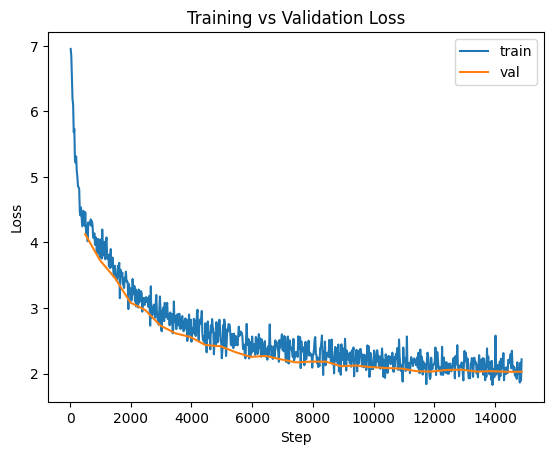

In [24]:

#logs = trainer.state.log_history
df = pd.DataFrame(logs)

train_loss = df[df["loss"].notna()]
val_loss = df[df["eval_loss"].notna()]

plt.plot(train_loss["step"], train_loss["loss"], label="train")
plt.plot(val_loss["step"], val_loss["eval_loss"], label="val")
plt.legend()
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.show()

In [25]:
import torch
import numpy as np
import pandas as pd
from torchvision.ops import box_iou
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
from scipy.optimize import linear_sum_assignment


@torch.no_grad()
def evaluate_detr_dataset_v6_hungarian(
    model,
    dataloader,
    image_processor,
    device,
    id2label,
    iou_threshold=0.5,
    score_threshold=0.3,   # changed from 0.05 to 0.3
):
    model.eval()
    model.to(device)

    total_predictions = 0
    total_gt = 0
    total_matches = 0
    correct_matches = 0
    sum_matched_iou = 0.0

    y_true = []
    y_pred = []

    for batch in dataloader:
        pixel_values = batch["pixel_values"].to(device)

        pixel_mask = batch.get("pixel_mask", None)
        if pixel_mask is not None:
            pixel_mask = pixel_mask.to(device)

        labels = [
            {k: v.to(device) for k, v in target.items()}
            for target in batch["labels"]
        ]

        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask)

        target_sizes = torch.stack([
            target["orig_size"].to(device)
            for target in labels
        ])

        results = image_processor.post_process_object_detection(
            outputs,
            threshold=score_threshold,
            target_sizes=target_sizes
        )

        for result, target in zip(results, labels):
            pred_boxes = result["boxes"]
            pred_labels = result["labels"]

            true_boxes = target["boxes"]
            true_labels = target["class_labels"]

            h, w = target["orig_size"]

            true_boxes_xyxy = torch.zeros_like(true_boxes)

            if true_boxes.numel() > 0:
                cx = true_boxes[:, 0] * w
                cy = true_boxes[:, 1] * h
                bw = true_boxes[:, 2] * w
                bh = true_boxes[:, 3] * h

                true_boxes_xyxy[:, 0] = cx - bw / 2
                true_boxes_xyxy[:, 1] = cy - bh / 2
                true_boxes_xyxy[:, 2] = cx + bw / 2
                true_boxes_xyxy[:, 3] = cy + bh / 2

            num_preds = len(pred_boxes)
            num_gt = len(true_boxes_xyxy)

            total_predictions += num_preds
            total_gt += num_gt

            if num_preds == 0 or num_gt == 0:
                continue

            ious = box_iou(pred_boxes, true_boxes_xyxy)

            cost_matrix = (-ious).detach().cpu().numpy()
            pred_indices, gt_indices = linear_sum_assignment(cost_matrix)

            for pred_idx, gt_idx in zip(pred_indices, gt_indices):
                iou = ious[pred_idx, gt_idx].item()

                if iou < iou_threshold:
                    continue

                total_matches += 1
                sum_matched_iou += iou

                gt_label = int(true_labels[gt_idx].item())
                pred_label = int(pred_labels[pred_idx].item())

                y_true.append(gt_label)
                y_pred.append(pred_label)

                if pred_label == gt_label:
                    correct_matches += 1

    # --------------------------------------------------
    # Confusion matrix: matched boxes only
    # --------------------------------------------------
    label_ids = sorted(id2label.keys())
    label_names = [id2label[i] for i in label_ids]

    cm = confusion_matrix(y_true, y_pred, labels=label_ids)

    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{name}" for name in label_names],
        columns=[f"pred_{name}" for name in label_names],
    )

    # --------------------------------------------------
    # A) Matched-only classification metrics
    # These match the confusion matrix.
    # They ignore unmatched GT and unmatched predictions.
    # --------------------------------------------------
    matched_accuracy = accuracy_score(y_true, y_pred) if len(y_true) > 0 else 0.0

    matched_precision_micro = precision_score(
        y_true, y_pred, labels=label_ids, average="micro", zero_division=0
    )

    matched_recall_micro = recall_score(
        y_true, y_pred, labels=label_ids, average="micro", zero_division=0
    )

    matched_f1_micro = f1_score(
        y_true, y_pred, labels=label_ids, average="micro", zero_division=0
    )

    matched_precision_macro = precision_score(
        y_true, y_pred, labels=label_ids, average="macro", zero_division=0
    )

    matched_recall_macro = recall_score(
        y_true, y_pred, labels=label_ids, average="macro", zero_division=0
    )

    matched_f1_macro = f1_score(
        y_true, y_pred, labels=label_ids, average="macro", zero_division=0
    )

    # --------------------------------------------------
    # B) Detection metrics including unmatched GT/preds
    # --------------------------------------------------
    unmatched_predictions = total_predictions - total_matches
    unmatched_gt = total_gt - total_matches
    wrong_class_matches = total_matches - correct_matches

    # Class-aware detection:
    # correct class + IoU match = TP
    # unmatched predictions + wrong-class matched preds = FP
    # unmatched GT + wrong-class matched GT = FN
    tp = correct_matches
    fp = unmatched_predictions + wrong_class_matches
    fn = unmatched_gt + wrong_class_matches

    detection_precision = tp / max(tp + fp, 1)
    detection_recall = tp / max(tp + fn, 1)
    detection_f1 = (
        2 * detection_precision * detection_recall /
        max(detection_precision + detection_recall, 1e-8)
    )

    # Localization-only detection:
    # ignores class correctness, only asks whether a GT was localized
    localization_precision = total_matches / max(total_predictions, 1)
    localization_recall = total_matches / max(total_gt, 1)
    localization_f1 = (
        2 * localization_precision * localization_recall /
        max(localization_precision + localization_recall, 1e-8)
    )

    mean_iou_matched = sum_matched_iou / max(total_matches, 1)

    print("===== DETR Dataset Evaluation V6: Hungarian Matching =====")
    print(f"IoU threshold: {iou_threshold}")
    print(f"Score threshold: {score_threshold}")
    print()
    print(f"Total predictions above threshold: {total_predictions}")
    print(f"Total ground-truth boxes: {total_gt}")
    print(f"Total matched pairs: {total_matches}")
    print(f"Correct class matched pairs: {correct_matches}")
    print(f"Unmatched predictions / FP candidates: {unmatched_predictions}")
    print(f"Unmatched GT / FN candidates: {unmatched_gt}")
    print(f"Wrong-class matched pairs: {wrong_class_matches}")
    print(f"Mean IoU of matched pairs: {mean_iou_matched:.4f}")

    print("\n---- A) Matched-only classification metrics ----")
    print("These match the confusion matrix and ignore unmatched GT/predictions.")
    print(f"Matched Accuracy:        {matched_accuracy:.4f}")
    print(f"Matched Precision micro: {matched_precision_micro:.4f}")
    print(f"Matched Recall micro:    {matched_recall_micro:.4f}")
    print(f"Matched F1 micro:        {matched_f1_micro:.4f}")
    print(f"Matched Precision macro: {matched_precision_macro:.4f}")
    print(f"Matched Recall macro:    {matched_recall_macro:.4f}")
    print(f"Matched F1 macro:        {matched_f1_macro:.4f}")

    print("\n---- B) Detection metrics including unmatched GT/predictions ----")
    print("These are stricter and should be used as real detection metrics.")
    print(f"Class-aware Precision: {detection_precision:.4f}")
    print(f"Class-aware Recall:    {detection_recall:.4f}")
    print(f"Class-aware F1:        {detection_f1:.4f}")

    print("\n---- C) Localization-only metrics ----")
    print("These ignore class correctness.")
    print(f"Localization Precision: {localization_precision:.4f}")
    print(f"Localization Recall:    {localization_recall:.4f}")
    print(f"Localization F1:        {localization_f1:.4f}")

    print("\nConfusion Matrix on Matched Boxes:")
    print(cm_df)

    return {
        "confusion_matrix_df": cm_df,
        "confusion_matrix": cm,

        "matched_accuracy": matched_accuracy,
        "matched_precision_micro": matched_precision_micro,
        "matched_recall_micro": matched_recall_micro,
        "matched_f1_micro": matched_f1_micro,
        "matched_precision_macro": matched_precision_macro,
        "matched_recall_macro": matched_recall_macro,
        "matched_f1_macro": matched_f1_macro,

        "class_aware_precision": detection_precision,
        "class_aware_recall": detection_recall,
        "class_aware_f1": detection_f1,

        "localization_precision": localization_precision,
        "localization_recall": localization_recall,
        "localization_f1": localization_f1,

        "mean_iou_matched": mean_iou_matched,
        "total_predictions": total_predictions,
        "total_gt": total_gt,
        "total_matches": total_matches,
        "correct_matches": correct_matches,
        "unmatched_predictions": unmatched_predictions,
        "unmatched_gt": unmatched_gt,
        "wrong_class_matches": wrong_class_matches,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "y_true": y_true,
        "y_pred": y_pred,
    }

In [26]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

In [29]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
val_metrics = evaluate_detr_dataset_v6_hungarian(
    model=model,
    dataloader=val_dataloader,
    image_processor=processor,
    device=device,
    id2label=model.config.id2label,
    iou_threshold=0.5,
    score_threshold=0.5
)

val_metrics["confusion_matrix_df"]


===== DETR Dataset Evaluation V6: Hungarian Matching =====
IoU threshold: 0.5
Score threshold: 0.5

Total predictions above threshold: 6742
Total ground-truth boxes: 4215
Total matched pairs: 3597
Correct class matched pairs: 3241
Unmatched predictions / FP candidates: 3145
Unmatched GT / FN candidates: 618
Wrong-class matched pairs: 356
Mean IoU of matched pairs: 0.7959

---- A) Matched-only classification metrics ----
These match the confusion matrix and ignore unmatched GT/predictions.
Matched Accuracy:        0.9010
Matched Precision micro: 0.9010
Matched Recall micro:    0.9010
Matched F1 micro:        0.9010
Matched Precision macro: 0.8268
Matched Recall macro:    0.8548
Matched F1 macro:        0.8376

---- B) Detection metrics including unmatched GT/predictions ----
These are stricter and should be used as real detection metrics.
Class-aware Precision: 0.4807
Class-aware Recall:    0.7689
Class-aware F1:        0.5916

---- C) Localization-only metrics ----
These ignore class c

,pred_premium,pred_single,pred_undersize,pred_abnormal
true_premium,2270,156,36,5
true_single,112,752,12,1
true_undersize,5,2,168,7
true_abnormal,2,7,11,51


In [30]:

# ============================================================
# INFERENCE
# ============================================================

def draw_boxes(image, boxes, labels, color, width=2):
    draw = ImageDraw.Draw(image)

    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = box
        draw.rectangle([x1, y1, x2, y2], outline=color, width=width)
        draw.text((x1, y1), label, fill=color)

    return image


def predict_and_draw(
    image_path,
    model,
    processor,
    id2label,
    gt_boxes=None,        # list of [x1,y1,x2,y2]
    gt_labels=None,       # list of class ids
    threshold=0.5,
    device=None
):
    if device is None:
        if torch.cuda.is_available():
            device = "cuda"
        elif torch.backends.mps.is_available():
            device = "mps"
        else:
            device = "cpu"

    model.to(device)
    model.eval()

    image = Image.open(image_path).convert("RGB")

    # -------- Prediction --------
    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    target_sizes = torch.tensor([image.size[::-1]], device=device)

    results = processor.post_process_object_detection(
        outputs=outputs,
        threshold=threshold,
        target_sizes=target_sizes
    )[0]

    pred_boxes = results["boxes"].cpu().numpy()
    pred_labels = results["labels"].cpu().numpy()
    pred_scores = results["scores"].cpu().numpy()

    pred_label_names = [
        f"{id2label[int(l)]}:{round(float(s),2)}"
        for l, s in zip(pred_labels, pred_scores)
    ]
    print(len(pred_boxes),len(gt_boxes))
    print(pred_scores)
    # -------- Draw --------
    image_draw = image.copy()

    # Draw ground truth (GREEN)
    if gt_boxes is not None and len(gt_boxes) > 0:
        gt_label_names = [id2label[int(l)] for l in gt_labels]
        image_draw = draw_boxes(image_draw, gt_boxes, gt_label_names, color="green")

    # Draw predictions (RED)
    image_draw = draw_boxes(image_draw, pred_boxes, pred_label_names, color="red")

    return image_draw

28 15
[0.9403782  0.86137366 0.66099864 0.74131763 0.9572801  0.5317277
 0.5953245  0.9207011  0.6585489  0.5484735  0.5438242  0.7094686
 0.87572736 0.6683826  0.83076614 0.91787285 0.7679497  0.73771554
 0.88184017 0.8413566  0.95443016 0.92588806 0.95427394 0.70682305
 0.55039686 0.6660077  0.7146938  0.63098055]


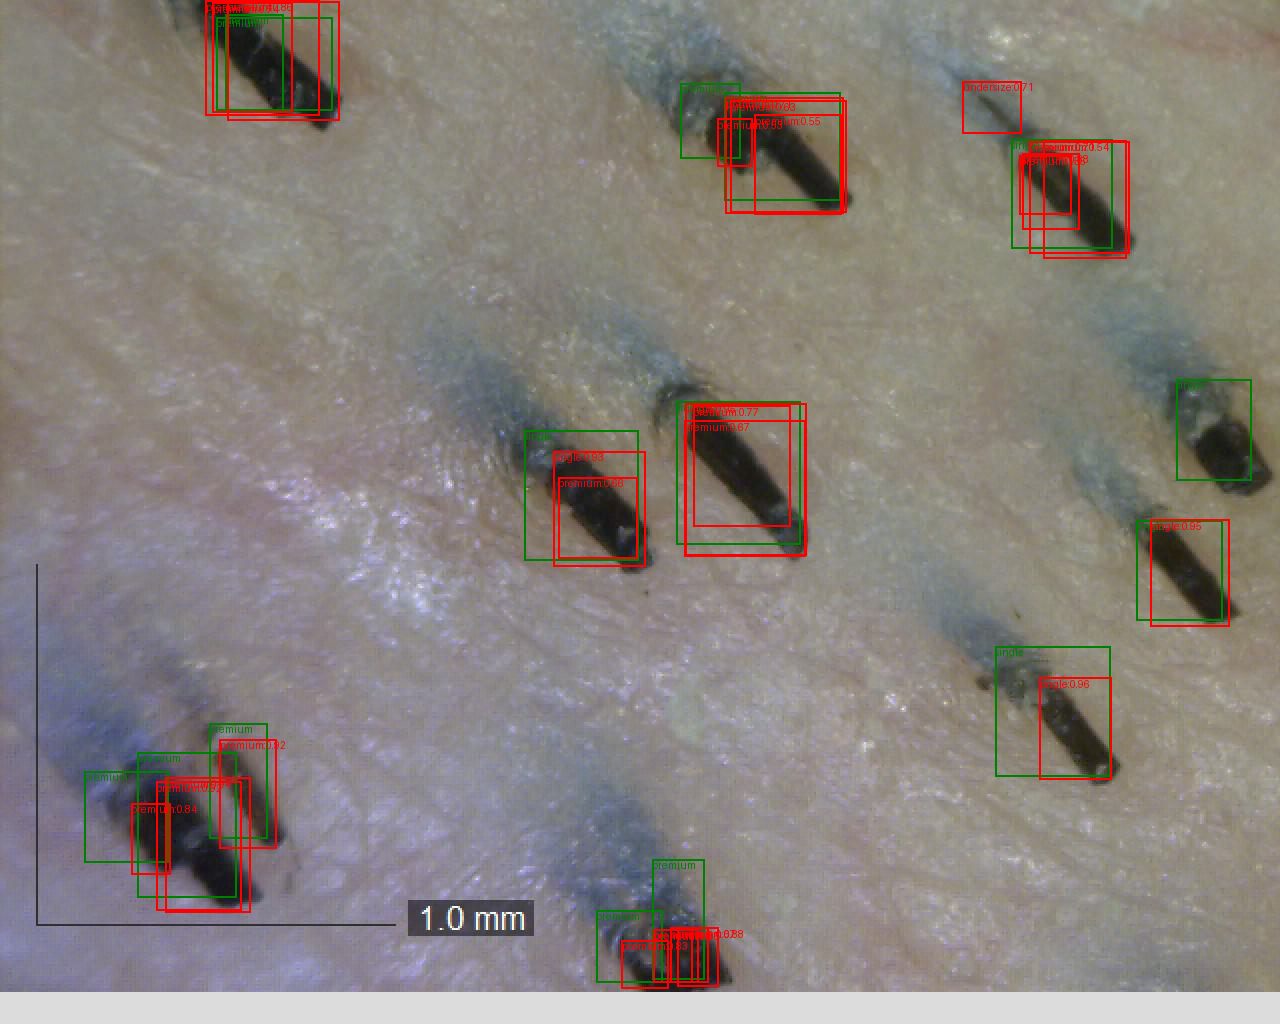

In [32]:
# Run test on single test image
#test
xml_path = '/content/data/Annotations/220105_A095_3.xml'
image_path = "/content/data/Images/220105_A095_3.jpg"
parsed = parse_voc_xml(xml_path, label2id)

gt_boxes = [obj["bbox_xyxy"] for obj in parsed["objects"]]
gt_labels = [obj["class_id"] for obj in parsed["objects"]]

img = predict_and_draw(
    image_path,
    model,
    processor,
    id2label,
    gt_boxes=gt_boxes,
    gt_labels=gt_labels,
    threshold=0.5
)

img